In [67]:
import qiskit
from qiskit import __version__
print(__version__)
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit import Parameter, ParameterVector
from qiskit.quantum_info import Statevector, SparsePauliOp, Pauli

import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib import cm

2.3.1


# Simple 1-qubit VQE 

In [68]:
# Define the hamiltonian

H = Pauli("-Z")
H.to_matrix()


array([[-1.+0.j,  0.+0.j],
       [ 0.+0.j,  1.-0.j]])

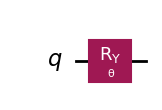

In [69]:
# Define the Ansatz

theta = Parameter('θ')
ansatz = QuantumCircuit(1)
ansatz.ry(theta, 0)

ansatz.draw('mpl')

In [70]:
# Define the cost function

estimator = StatevectorEstimator()

def cost(params):
    bound_ansatz = ansatz.assign_parameters({theta: params[0]})

    pub = (bound_ansatz, H)
    job = estimator.run([pub])
    result = job.result()[0]

    # return the energy
    return result.data.evs



In [71]:
# run the classical optimization loop

init_theta = [0.0]

result = sp.minimize(cost, init_theta, method="COBYLA")

print(f"Optimization Converged: {result.success}")
print(f"Optimal Parameter θ: {result.x[0]:.4f} radians")
print(f"Estimated Ground State Energy: {result.fun:.4f}")

Optimization Converged: True
Optimal Parameter θ: 0.0000 radians
Estimated Ground State Energy: -1.0000


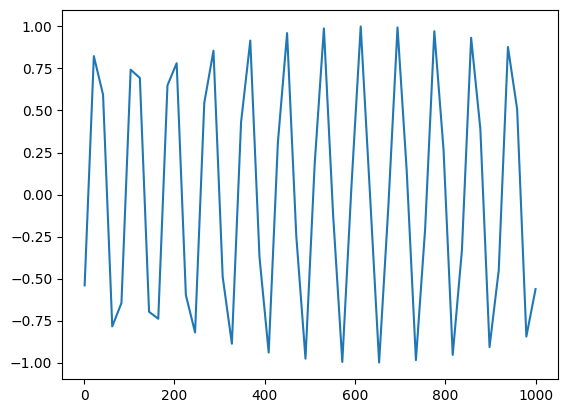

In [72]:
# visualize the parameter space (where barren plateaus live)

xs = np.linspace(1, 1000)
ys = [cost([x]) for x in xs]

plt.plot(xs, ys)

### Lets go bigger -> 2 qubit VQA (so the parameter space is 3 dimensional)
Entanglement!

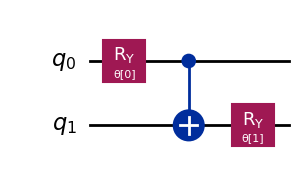

In [73]:
# 1. Hamiltonian (ZI + IZ + 0.5*XX)
hamiltonian = SparsePauliOp.from_list([("ZI", 1.0), ("IZ", 1.0), ("XX", 0.5)])

# 2. 2-Parameter Ansatz
theta = ParameterVector('θ', 2)
ansatz = QuantumCircuit(2)
ansatz.ry(theta[0], 0)  # Parameter 1
ansatz.cx(0, 1)
ansatz.ry(theta[1], 1)  # Parameter 2

ansatz.draw('mpl')

In [74]:
estimator = StatevectorEstimator()

def compute_energy(theta0_val, theta1_val):
    # Bind the specific pair of parameters
    bound_ansatz = ansatz.assign_parameters({theta[0]: theta0_val, theta[1]: theta1_val})
    
    pub = (bound_ansatz, hamiltonian)
    job = estimator.run([pub])
    return job.result()[0].data.evs

In [75]:
# Generate 50 points between -pi and pi for both parameters
x = np.linspace(-np.pi, np.pi, 50)
y = np.linspace(-np.pi, np.pi, 50)
X, Y = np.meshgrid(x, y)

# Pre-allocate the energy grid
Z = np.zeros(X.shape)

# Fill the grid with expectation values
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = compute_energy(X[i, j], Y[i, j])

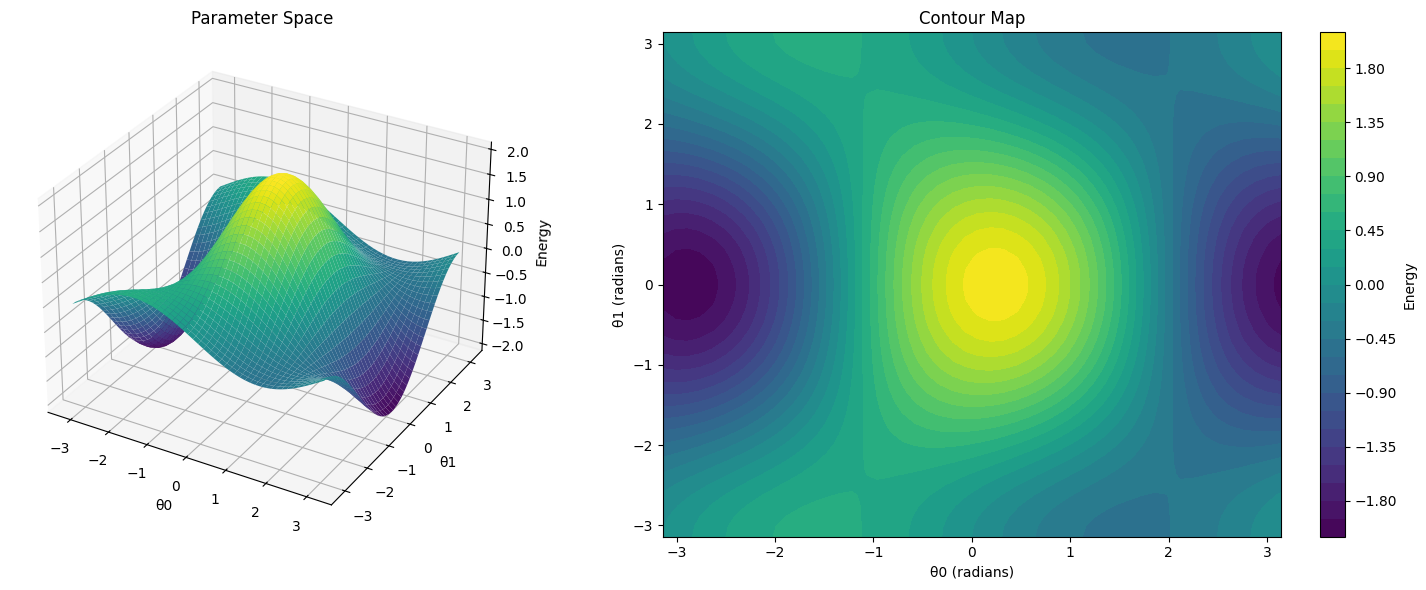

In [76]:
# Create a figure canvas for two plots side-by-side
fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')

surf = ax1.plot_surface(
    X, 
    Y, 
    Z, 
    cmap=cm.viridis,
    linewidth=0, 
    antialiased=True
)

ax1.set_title('Parameter Space')
ax1.set_xlabel('θ0')
ax1.set_ylabel('θ1')
ax1.set_zlabel('Energy')

ax2 = fig.add_subplot(1, 2, 2)

contour = ax2.contourf(X, Y, Z, levels=30, cmap=cm.viridis)
fig.colorbar(contour, ax=ax2, label='Energy')

ax2.set_title('Contour Map')
ax2.set_xlabel('θ0 (radians)')
ax2.set_ylabel('θ1 (radians)')

plt.tight_layout()
plt.show()

In [ ]:

# This list will store the path the optimizer takes
training_path = []

def training_cost_function(params):
    theta0_val, theta1_val = params
    energy = compute_energy(theta0_val, theta1_val)
    
    # Save the current parameters and the resulting energy
    training_path.append([theta0_val, theta1_val, energy])
    return energy

# 1. Choose a random starting point in our landscape
# For example, near the top right: θ₀ = 2.0, θ₁ = 2.0
initial_guess = [2.0, 2.0]

# 2. Run the classical optimizer
result = minimize(training_cost_function, initial_guess, method='COBYLA')

# Convert our path history into a handy numpy array
path = np.array(training_path)

print(f"Training Converged: {result.success}")
print(f"Final Optimal Parameters: θ_0 = {result.x[0]:.4f}, θ_1 = {result.x[1]:.4f}")
print(f"Minimum Energy Found: {result.fun:.4f}")

Training Converged: True
Final Optimal Parameters: θ0 = 3.3866, θ1 = -0.0000
Minimum Energy Found: -2.0616
